In [ ]:
import torch
torch.set_num_threads(4)
print (torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [ ]:
import torchvision.models as models

model = models.resnet18(weights= "IMAGENET1K_V1")
model.eval()

print(model.__class__.__name__)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

ResNet
Number of parameters: 11689512


In [ ]:
import torch
import time

# Create a batch of 8 fake images
batch_size = 8
dummy_input = torch.randn(batch_size, 3, 224, 224)

# Move model and data tp CPU explicitly for now
device = torch.device("cpu")
model.to(device)
dummy_input = dummy_input.to(device)

# Time a single inference pass
start = time.time()
with torch.no_grad():
  output = model(dummy_input)
end = time.time()

print("Output shape:", output.shape)
print(f"Time taken:{end - start:.4f} seconds")



Output shape: torch.Size([8, 1000])
Time taken:0.5082 seconds


In [ ]:
import torch
import time

def benchmark(model, device, batch_size, n_runs=10):
    model.to(device)
    dummy_input = torch.randn(batch_size, 3, 224, 224).to(device)

    # Warm-up run (not timed)
    with torch.no_grad():
      _ = model(dummy_input)
    if device.type == "cuda":
       torch.cuda.synchronize()

    start = time.time()
    with torch.no_grad():
      for _ in range(n_runs):
        output = model(dummy_input)
    if device.type == "cuda":
      torch.cuda.synchronize()
    end = time.time()


    avg_time = (end - start) / n_runs
    throughput = batch_size / avg_time
    return avg_time, throughput







In [ ]:
device = torch.device("cpu")
avg_time, throughput = benchmark(model, device, batch_size=8,n_runs=3)
print(f"CPU | batch=8 | avg time: {avg_time:.4f}s | throughput: {throughput:.1f} images/sec")

CPU | batch=8 | avg time: 0.3397s | throughput: 23.5 images/sec


In [ ]:
print("Threads PyTorch is using:",  torch.get_num_threads())

Threads PyTorch is using: 1


In [ ]:
device = torch.device("cuda")
avg_time, throughput = benchmark(model, device, batch_size=8, n_runs=10)
print(f"GPU | batch=8 | avg time: {avg_time:.4f}s | throughput: {throughput:.1f} images/sec")

GPU | batch=8 | avg time: 0.0138s | throughput: 578.0 images/sec


In [ ]:
batch_sizes = [1, 8, 32, 128]
results = []

for bs in batch_sizes:
  for device_name in ["cpu", "cuda"]:
    device = torch.device(device_name)
    avg_time, throughput = benchmark(model, device, batch_size=bs, n_runs=10)
    results.append({
        "device": device_name,
        "batch_size": bs,
        "throughput": throughput
    })
    print(f"{device_name.upper():4} | batch={bs:4} | time: {avg_time:.4f}s | throughput: {throughput:.1f} img/s")

CPU  | batch=   1 | time: 0.0969s | throughput: 10.3 img/s
CUDA | batch=   1 | time: 0.0039s | throughput: 256.3 img/s
CPU  | batch=   8 | time: 0.3579s | throughput: 22.4 img/s
CUDA | batch=   8 | time: 0.0138s | throughput: 581.5 img/s
CPU  | batch=  32 | time: 1.6231s | throughput: 19.7 img/s
CUDA | batch=  32 | time: 0.0324s | throughput: 987.9 img/s
CPU  | batch= 128 | time: 7.3030s | throughput: 17.5 img/s
CUDA | batch= 128 | time: 0.1089s | throughput: 1175.1 img/s


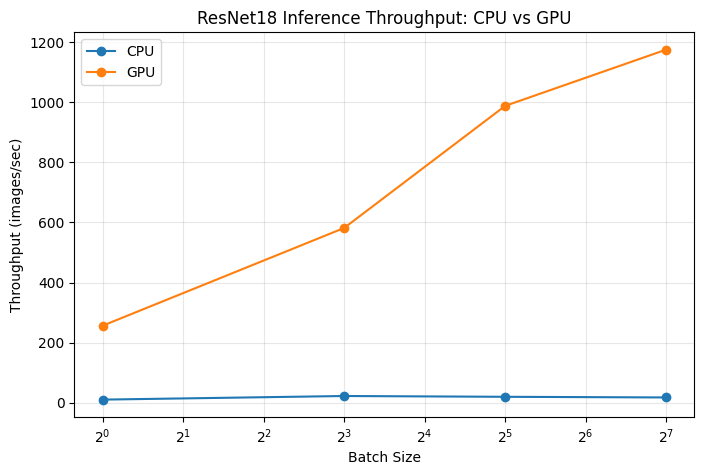

In [ ]:
import matplotlib.pyplot as plt

cpu_results = [r for r in results if r["device"] == "cpu"]
gpu_results = [r for r in results if r["device"] == "cuda"]

plt.figure(figsize=(8, 5))
plt.plot([r["batch_size"] for r in cpu_results], [r["throughput"] for r in cpu_results], marker='o', label='CPU')
plt.plot([r["batch_size"] for r in gpu_results], [r["throughput"] for r in gpu_results], marker='o', label='GPU')
plt.xlabel("Batch Size")
plt.ylabel("Throughput (images/sec)")
plt.title("ResNet18 Inference Throughput: CPU vs GPU")
plt.xscale("log", base=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()